# Metodo delle potenze e PageRank

Molti problemi applicativi non richiedono lo spettro completo di una matrice, ma solo il suo autovalore di modulo massimo (l'autovalore *dominante*) e il corrispondente autovettore: basti pensare a un sistema dinamico lineare $x_{k+1}=Ax_k$, il cui comportamento a lungo termine è governato proprio da quell'autovalore. Il **metodo delle potenze** sfrutta questa osservazione: invece di risolvere il problema agli autovalori nella sua interezza, costruisce iterativamente una successione di vettori che converge (sotto opportune ipotesi) alla direzione dell'autovettore dominante, da cui si ricava anche l'autovalore corrispondente.

In questo notebook si costruisce dapprima il metodo nella sua versione più semplice, se ne osserva un limite pratico legato alla crescita numerica del vettore iterato, e lo si corregge con una versione normalizzata. Si applica infine lo stesso identico algoritmo a un problema concreto: calcolare l'importanza relativa delle pagine di una piccola rete di link, ovvero il **PageRank**, mostrando che quest'ultimo altro non è che un caso particolare del metodo delle potenze applicato a una matrice costruita a partire dalla struttura dei collegamenti tra pagine.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from src.power_method import power_method, power_method_norm

## Una matrice di riferimento

Per costruire e verificare il metodo delle potenze conviene partire da una matrice di cui si conoscono già tutti gli autovalori "esatti", calcolati con un metodo diretto: solo così è possibile controllare, passo dopo passo, se l'iterazione converge davvero al valore atteso e con quale velocità.

Si consideri la matrice reale $3\times 3$

$$
A = \begin{pmatrix} 6 & 2 & 1 \\ 1 & 5 & 1 \\ 1 & 1 & 4 \end{pmatrix}.
$$

Se ne calcolano gli autovalori con un metodo diretto (la decomposizione spettrale completa), che in NumPy corrisponde alla funzione `numpy.linalg.eig`. Questo passaggio serve solo da riferimento: per una matrice di dimensione $n$ qualunque, calcolare l'intero spettro ha un costo computazionale molto più alto rispetto a stimare il solo autovalore dominante, che è invece l'obiettivo del metodo delle potenze introdotto nella sezione successiva.

In [2]:
A = np.array([[6, 2, 1],
              [1, 5, 1],
              [1, 1, 4]], dtype=float)

l, v = np.linalg.eig(A)

print("Autovalori di A:", l)
print("Matrice degli autovettori corrispondenti:\n", v)

Autovalori di A: [7.56155281+0.j 4.        +0.j 3.43844719+0.j]
Matrice degli autovettori corrispondenti:
 [[-8.14442028e-01+0.j -7.07106781e-01+0.j  1.70270006e-01+0.j]
 [-4.57352212e-01+0.j  7.07106781e-01+0.j -6.06425619e-01+0.j]
 [-3.57089816e-01+0.j -2.02764342e-15+0.j  7.76695625e-01+0.j]]


$A$ ha tre autovalori reali e distinti, circa $\lambda_1\approx 7.56$, $\lambda_2 = 4.00$, $\lambda_3\approx 3.44$. L'autovalore dominante $\lambda_1$ è ben separato dal secondo in modulo: il rapporto

$$
\left|\frac{\lambda_2}{\lambda_1}\right| \approx 0.53
$$

sarà il parametro chiave per la velocità di convergenza del metodo delle potenze: come si vedrà, l'errore dell'iterazione decresce geometricamente con ragione proprio pari a questo rapporto, quindi una buona separazione tra $\lambda_1$ e $\lambda_2$ garantisce una convergenza rapida.

## Il metodo delle potenze nella sua versione grezza

L'idea di base è semplice: partendo da un vettore iniziale arbitrario $u_0$ (non ortogonale alla direzione dominante), si costruisce la successione

$$
u_{k+1} = A\,u_k,
$$

e si dimostra che, sotto l'ipotesi che $A$ abbia un unico autovalore di modulo massimo, la direzione di $u_k$ converge a quella dell'autovettore dominante. Una stima dell'autovalore dominante a ogni passo si ottiene dal quoziente

$$
\lambda_{k+1} = \frac{u_k^{\mathsf T} u_{k+1}}{u_k^{\mathsf T} u_k},
$$

che è invariante per riscalamento di $u_k$ (moltiplicare $u_k$ per una costante non cambia il valore del quoziente). Come criterio d'arresto si usa la differenza fra due stime successive di $\lambda$,

$$
\text{err} := |\lambda_{k+1} - \lambda_k| < \text{tol},
$$

insieme a un numero massimo di iterazioni come salvaguardia.

In [3]:
lam, u1, n_it, err, approx = power_method(np.array([1., 1., 1.]), A, 1e-10, 3000)

print("Autovalore stimato:", lam)
print("Numero di iterazioni impiegate:", n_it)
print("Norma del vettore iterato finale:", np.linalg.norm(u1))
print("Errore all'ultimo passo:", err[-1])

Autovalore stimato: 7.561552812885152
Numero di iterazioni impiegate: 35
Norma del vettore iterato finale: 7.421591067880027e+31
Errore all'ultimo passo: 6.790390472133367e-11


Il valore di $\lambda$ trovato coincide, entro la tolleranza richiesta, con l'autovalore dominante calcolato in precedenza in modo diretto: il quoziente usato come stima è dunque corretto, ed è anche invariante rispetto alla scala di $u_k$, quindi in linea di principio nessuna normalizzazione dovrebbe essere necessaria per ottenere $\lambda$.

Il problema pratico è un altro: la **norma** del vettore iterato $u_k$ non è per nulla invariante. Ad ogni passo $u_{k+1}=Au_k$ viene moltiplicata approssimativamente per $|\lambda_1|$, quindi dopo $k$ iterazioni $\|u_k\|$ cresce grosso modo come $|\lambda_1|^k$. Con $|\lambda_1|\approx 7.56$ bastano poche decine di iterazioni perché questa crescita diventi enorme, come mostra il valore della norma appena stampato — dell'ordine di $10^{31}$ dopo poche decine di passi. Su un problema con un autovalore dominante più grande, o con una tolleranza più stretta che richieda più iterazioni, questa crescita esponenziale porterebbe rapidamente a un overflow numerico (valori che superano la capacità rappresentativa dei numeri in virgola mobile), oppure, se $|\lambda_1|<1$, al fenomeno opposto: un underflow che azzera silenziosamente il vettore. In entrambi i casi il metodo smetterebbe di funzionare correttamente. È questo limite pratico — non un errore nella formula del quoziente — a motivare una versione del metodo in cui il vettore iterato viene tenuto a norma costante a ogni passo.

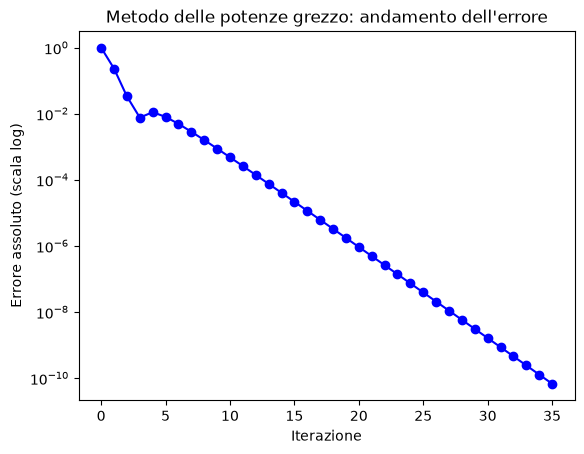

In [4]:
plt.semilogy(range(len(err)), err, "-ob")
plt.xlabel("Iterazione")
plt.ylabel("Errore assoluto (scala log)")
plt.title("Metodo delle potenze grezzo: andamento dell'errore")
plt.show()

## La correzione: normalizzare a ogni passo

La correzione è diretta: si tiene il vettore iterato a norma 1 dopo ogni moltiplicazione per $A$. Definendo $z_k := u_k/\|u_k\|$, la ricorsione diventa

$$
u_{k+1} = A\,z_k, \qquad z_{k+1} = \frac{u_{k+1}}{\|u_{k+1}\|},
$$

e la stima dell'autovalore usa lo stesso quoziente di prima, con $z_k$ al posto di $u_k$:

$$
\lambda_{k+1} = \frac{z_k^{\mathsf T} u_{k+1}}{z_k^{\mathsf T} z_k} = z_k^{\mathsf T} u_{k+1}
$$

(l'ultima uguaglianza vale perché $\|z_k\|=1$, quindi $z_k^{\mathsf T} z_k = 1$). Il criterio d'arresto resta lo stesso, $|\lambda_{k+1}-\lambda_k|<\text{tol}$.

In [5]:
lamN, zN, n_itN, errN, approxN = power_method_norm(np.array([1., 1., 1.]), A, 1e-10, 3000)

print("Autovalore stimato:", lamN)
print("Numero di iterazioni impiegate:", n_itN)
print("Norma del vettore iterato finale:", np.linalg.norm(zN))
print("Errore all'ultimo passo:", errN[-1])

Autovalore stimato: 7.561552812885152
Numero di iterazioni impiegate: 35
Norma del vettore iterato finale: 1.0
Errore all'ultimo passo: 6.790390472133367e-11


Il confronto con la versione precedente è istruttivo. L'autovalore stimato e il numero di iterazioni impiegate sono **identici** in entrambe le versioni: questo non è un caso, perché il quoziente che stima $\lambda$ è già invariante rispetto alla scala del vettore, quindi la normalizzazione non ne cambia il comportamento numerico né la velocità di convergenza — quest'ultima dipende solo dal rapporto $|\lambda_2/\lambda_1|$ visto in apertura, non da come si gestisce la norma del vettore.

Ciò che cambia radicalmente è la norma del vettore iterato: qui resta esattamente 1 a ogni passo, per costruzione, invece di crescere fino a un valore dell'ordine di $10^{31}$ come nella versione grezza. Il vantaggio della normalizzazione è dunque puramente di **robustezza numerica**: lo stesso identico algoritmo, applicato a una matrice con un autovalore dominante più grande o eseguito per molte più iterazioni, nella versione grezza andrebbe incontro a overflow (o underflow, se $|\lambda_1|<1$), mentre nella versione normalizzata resta ben definito indefinitamente.

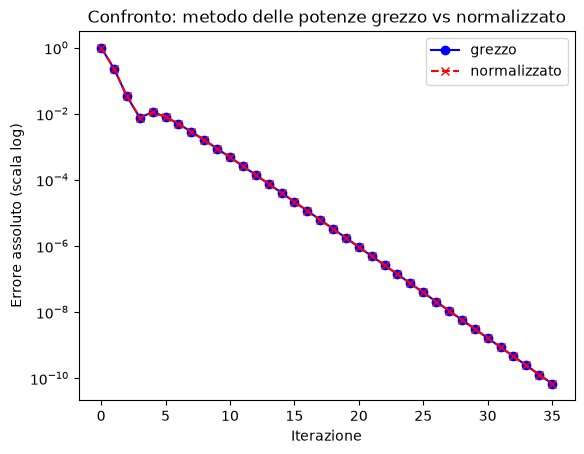

In [6]:
plt.semilogy(range(len(err)), err, "-ob", label="grezzo")
plt.semilogy(range(len(errN)), errN, "--xr", label="normalizzato")
plt.xlabel("Iterazione")
plt.ylabel("Errore assoluto (scala log)")
plt.title("Confronto: metodo delle potenze grezzo vs normalizzato")
plt.legend()
plt.show()

## PageRank: l'importanza di una pagina come autovettore dominante

Si consideri ora una piccola rete di 6 pagine web, collegate fra loro dai seguenti link (ogni pagina distribuisce lo stesso "peso" fra tutti i link che contiene):

- pagina 1 → pagine 2, 3, 4
- pagina 2 → pagine 1, 3
- pagina 3 → pagina 4
- pagina 4 → pagina 1
- pagina 5 → pagine 1, 2, 6
- pagina 6 → nessun link in uscita

L'idea del PageRank è che una pagina è tanto più importante quante più pagine (a loro volta importanti) la collegano: è una definizione intrinsecamente ricorsiva, che porta esattamente al problema di trovare l'autovettore dominante di un'opportuna matrice costruita dai link — lo stesso problema affrontato finora, applicato a un caso concreto invece che a una matrice numerica astratta.

La pagina 6, non avendo link in uscita, è un caso particolare (**nodo dangling**): va gestita a parte, perché altrimenti "disperderebbe" tutta l'importanza che riceve senza restituirne a nessuno.

In [7]:
n = 6
H = np.zeros((n, n))

# colonna j = pesi dei link in uscita dalla pagina j (indici 0-based: pagina i = indice i-1)
H[1, 0] = 1/3; H[2, 0] = 1/3; H[3, 0] = 1/3   # pagina 1 -> 2,3,4
H[0, 1] = 1/2; H[2, 1] = 1/2                   # pagina 2 -> 1,3
H[3, 2] = 1                                     # pagina 3 -> 4
H[0, 3] = 1                                     # pagina 4 -> 1
H[0, 4] = 1/3; H[1, 4] = 1/3; H[5, 4] = 1/3   # pagina 5 -> 1,2,6
# colonna 5 (pagina 6) resta tutta a zero: nodo dangling

print("Matrice H:\n", H)
print("Somme per colonna di H:", H.sum(axis=0))

Matrice H:
 [[0.         0.5        0.         1.         0.33333333 0.        ]
 [0.33333333 0.         0.         0.         0.33333333 0.        ]
 [0.33333333 0.5        0.         0.         0.         0.        ]
 [0.33333333 0.         1.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.33333333 0.        ]]
Somme per colonna di H: [1. 1. 1. 1. 1. 0.]


Come atteso, tutte le colonne di $H$ sommano a 1 tranne l'ultima (pagina 6), che somma a 0: è esattamente il nodo dangling.

Per evitare che questa colonna "disperda" importanza nel nulla, si costruisce $S$ sostituendo la colonna dangling con un vettore uniforme $1/n$ (come se la pagina 6 linkasse, con uguale probabilità, a tutte le pagine della rete, incluse sé stessa). Infine si definisce la **matrice di Google**

$$
G = \alpha\,S + \frac{1-\alpha}{n}\,\mathbf{1},
$$

dove $\mathbf{1}$ è la matrice $n\times n$ di tutti 1 e $\alpha=0.85$ è il fattore di smorzamento standard della formula originale di Brin e Page: rappresenta la probabilità che, navigando, si segua un link della pagina corrente, contro una probabilità $1-\alpha$ di saltare a una pagina qualsiasi scelta a caso. Questa combinazione garantisce che $G$ sia una matrice primitiva e irriducibile, condizione che per il teorema di Perron-Frobenius assicura l'esistenza di un unico autovalore dominante reale e positivo (che risulterà essere esattamente 1, essendo $G$ colonna-stocastica) con autovettore a componenti tutte positive — l'unico ranking ben definito delle pagine.

In [8]:
S = H.copy()
dangling_cols = np.where(H.sum(axis=0) == 0)[0]
for j in dangling_cols:
    S[:, j] = 1/n

alpha = 0.85
G = alpha*S + (1-alpha)/n*np.ones((n, n))

print("Matrice di Google G:\n", G)
print("Somme per colonna di G:", G.sum(axis=0))

Matrice di Google G:
 [[0.025      0.45       0.025      0.875      0.30833333 0.16666667]
 [0.30833333 0.025      0.025      0.025      0.30833333 0.16666667]
 [0.30833333 0.45       0.025      0.025      0.025      0.16666667]
 [0.30833333 0.025      0.875      0.025      0.025      0.16666667]
 [0.025      0.025      0.025      0.025      0.025      0.16666667]
 [0.025      0.025      0.025      0.025      0.30833333 0.16666667]]
Somme per colonna di G: [1. 1. 1. 1. 1. 1.]


Con $G$ costruita e verificata, resta solo da applicarle il metodo delle potenze normalizzato definito in precedenza — nessuna funzione nuova, lo stesso `power_method_norm` usato sulla matrice $A$ dell'inizio del notebook.

In [9]:
u0 = np.random.default_rng(0).random(n)
lamG, zG, n_itG, errG, approxG = power_method_norm(u0, G, 1e-8, 200)

importanza = zG / zG.sum()   # rinormalizzata a somma 1, interpretabile come probabilità
ranking = np.argsort(-importanza) + 1   # +1 per riportare la numerazione delle pagine da 1

print("Autovalore dominante (atteso 1, matrice colonna-stocastica):", lamG)
print("Numero di iterazioni impiegate:", n_itG)
print("Importanza delle pagine (normalizzata a somma 1):", importanza)
print("Ranking pagine (dalla più importante alla meno importante):", ranking)

Autovalore dominante (atteso 1, matrice colonna-stocastica): 0.9999999981305582
Numero di iterazioni impiegate: 28
Importanza delle pagine (normalizzata a somma 1): [0.3341572  0.13389023 0.18213631 0.28004882 0.03055508 0.03921236]
Ranking pagine (dalla più importante alla meno importante): [1 4 3 2 6 5]


Il risultato conferma quanto previsto dalla teoria: l'autovalore dominante di $G$ è (a meno di errori numerici) esattamente 1, come deve essere per una matrice colonna-stocastica, ed è stato ottenuto con la stessa identica funzione `power_method_norm` usata nella prima parte del notebook, senza alcuna modifica — il PageRank non richiede un algoritmo dedicato, ne è semplicemente un'applicazione.

Il ranking risultante è coerente con la struttura del grafo: la pagina 1 risulta la più importante, perché è l'unica a ricevere link da tre pagine diverse (2, 4 e 5). La pagina 5, al contrario, risulta la meno importante: pur linkando ad altre tre pagine, non riceve alcun link in ingresso da nessuna delle altre, quindi la sua importanza deriva unicamente dal termine di teletrasporto uniforme $(1-\alpha)/n$ comune a tutte le pagine. Anche la pagina 6 (il nodo dangling) riceve importanza minima, coerentemente col fatto di essere collegata solo dalla pagina 5, essa stessa poco importante — un effetto ricorsivo tipico di questa misura: essere linkati da pagine poco importanti aiuta poco, indipendentemente da quanti link si ricevono.